In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# 1. 뉴스 데이터 전처리 및 임베딩 생성 중간점검
# 데이터 불러오기
stock_df = pd.read_csv('C:\\Users\\jinfo\\Desktop\\Programming\\capstone_project\\stock_data.csv')
news_df = pd.read_csv('C:\\Users\\jinfo\\Desktop\\Programming\\capstone_project\\news_data.csv')

# 변수명 변경 (기존 코드와 연결 위해)
stock = stock_df.copy()
news = news_df.copy()

# 결측치 확인
print("\n뉴스 데이터 결측치 개수:")
print(news.isnull().sum())


뉴스 데이터 결측치 개수:
date        3
title       0
summary    20
related     0
dtype: int64


In [7]:
# 결측값이 있는 행 삭제
news['summary'] = news['summary'].fillna('')
news = news.dropna(subset=['date'])

print("\n뉴스 데이터 결측치 개수(삭제 후):")
print(news.isnull().sum())


뉴스 데이터 결측치 개수(삭제 후):
date       0
title      0
summary    0
related    0
dtype: int64


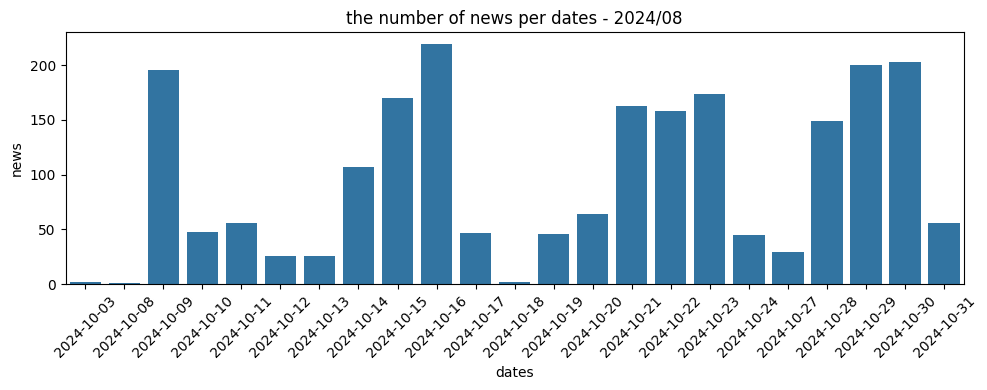

In [8]:
# 2. 2020년 8월 뉴스 데이터 시각화
news['date'] = pd.to_datetime(news['date'])
month = 10
year = 2024
news_aug2020 = news[(news['date'].dt.year == year) & (news['date'].dt.month == month)]

news_per_date_aug2020 = news_aug2020.groupby(news_aug2020['date'].dt.date).size()

plt.figure(figsize=(10,4))
sns.barplot(x=news_per_date_aug2020.index, y=news_per_date_aug2020.values)
plt.title("the number of news per dates - 2024/08")
plt.xlabel("dates")
plt.ylabel("news")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

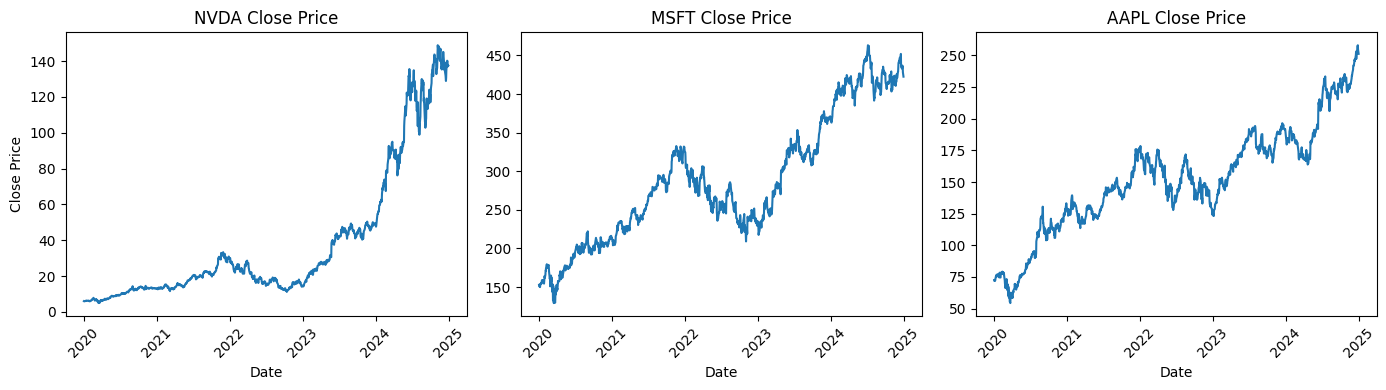

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

symbols = stock['Symbol'].unique()
plt.figure(figsize=(14, 4))  # 1행 3열, 작게

for i, symbol in enumerate(symbols):
    plt.subplot(1, 3, i + 1)
    subset = stock[stock['Symbol'] == symbol].sort_values(by='Date')
    dates = pd.to_datetime(subset['Date'])
    closes = subset['Close']

    sns.lineplot(x=dates, y=closes)
    plt.title(f"{symbol} Close Price")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.xticks(rotation=45)
    if i > 0:
        plt.ylabel("")  # 두 번째, 세 번째 그래프는 y축 라벨 생략해도 됨

plt.tight_layout()
plt.show()

finbert-tone 임베딩 생성 완료


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

c:\Users\jinfo\Desktop\Programming\capstone_project\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jinfo\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

prosus-finbert 임베딩 생성 완료
finbert-2025 임베딩 생성 실패: Repo id must be in the form 'repo_name' or 'namespace/repo_name': 'PATH/TO/FINBERT-2025-최신-모델'. Use `repo_type` argument if needed.


c:\Users\jinfo\Desktop\Programming\capstone_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jinfo\Desktop\Programming\capstone_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jinfo\Desktop\Programming\capstone_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jinfo\Desktop\Programming\capstone_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45684 (\N{HANGUL SYLLABLE NYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jinfo\Desktop\Programming\capstone_project\.venv\L

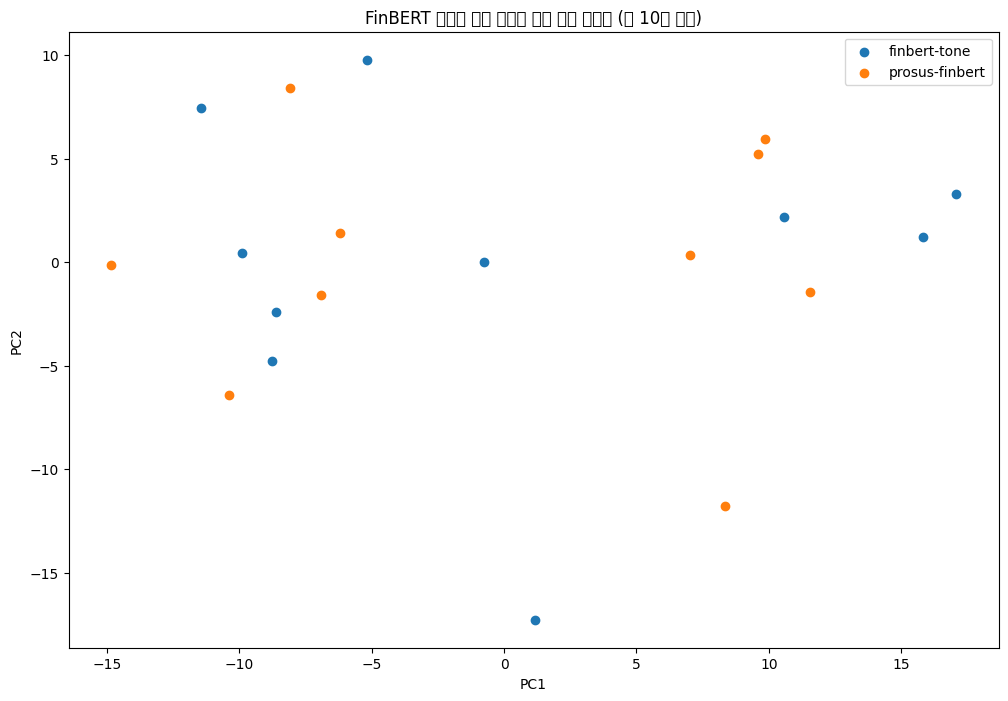

In [15]:
from transformers import AutoTokenizer, AutoModel

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# # 데이터 불러오기
# stock_df = pd.read_csv('C:\\Users\\jinfo\\Desktop\\Programming\\capstone_project\\stock_data.csv')
# news_df = pd.read_csv('C:\\Users\\jinfo\\Desktop\\Programming\\capstone_project\\news_data.csv')
# stock = stock_df.copy()
# news = news_df.copy()

# news['date'] = pd.to_datetime(news['date'])

# FinBERT 모델 리스트
model_names = {
    "finbert-tone": "yiyanghkust/finbert-tone",
    "prosus-finbert": "ProsusAI/finbert",
    "finbert-2025": "PATH/TO/FINBERT-2025-최신-모델"  # 실제 경로/모델명 입력
}

def load_model_and_tokenizer(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()
    return tokenizer, model

def get_embeddings(texts, tokenizer, model, batch_size=16):
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True, max_length=512)
            outputs = model(**inputs)
            batch_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_emb)
    return np.array(embeddings)

news_texts = news['title'] + ' ' + news.get('summary', '')

embeddings_dict = {}
for key, model_name in model_names.items():
    try:
        tokenizer, model = load_model_and_tokenizer(model_name)
        embeddings = get_embeddings(list(news_texts), tokenizer, model)
        embeddings_dict[key] = embeddings
        print(f"{key} 임베딩 생성 완료")
    except Exception as e:
        print(f"{key} 임베딩 생성 실패: {e}")

pca = PCA(n_components=2)
plt.figure(figsize=(12,8))

for key, emb in embeddings_dict.items():
    if emb.shape[0] >= 10:
        emb_subset = emb[:10]
        emb_2d = pca.fit_transform(emb_subset)
        plt.scatter(emb_2d[:, 0], emb_2d[:, 1], label=key)

plt.title("FinBERT 모델별 뉴스 임베딩 차원 축소 시각화 (첫 10개 샘플)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()


In [20]:
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np

# FinBERT 토크나이저와 모델 로드
tokenizer = AutoTokenizer.from_pretrained('yiyanghkust/finbert-tone')
model_bert = AutoModel.from_pretrained('yiyanghkust/finbert-tone')


# 임베딩 생성 함수 (batch 단위, CLS 토큰 벡터)
def finbert_sentiment_score(texts, batch_size=16):
    embeddings = []
    model_bert.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True, max_length=512)
            outputs = model_bert(**inputs)
            batch_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_emb)
    return np.array(embeddings)


In [21]:
# 임베딩 생성
news_embeddings = finbert_sentiment_score(news['title'] + ' ' + news['summary'])
news['embedding'] = list(news_embeddings)

ValueError: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples).

In [17]:
# 1) 날짜/종목별, 임베딩 평균값 계산 (대표 임베딩)
def daily_embedding(emb_list):
    return np.mean(np.stack(emb_list), axis=0)
news_date_group = news.groupby(['date', 'related'])['embedding'] \
                      .apply(daily_embedding) \
                      .reset_index() \
                      .rename(columns={'embedding':'daily_sentiment_embedding'})

# 2) 주가 데이터 날짜 처리 및 병합
stock['Date'] = pd.to_datetime(stock['Date']).dt.date
data = pd.merge(news_date_group, stock, how='inner', left_on=['date','related'], right_on=['Date','Symbol'])

# 3) 병합 데이터 점검
print("\nMerged data sample:")
print(data.head())

print("\nMissing values in merged data:")
print(data.isnull().sum())

# 날짜별 데이터 수 시각화
data_per_date = data.groupby('date').size()
plt.figure(figsize=(12,4))
sns.lineplot(x=data_per_date.index, y=data_per_date.values)
plt.title("Number of Records per Date in Merged Data")
plt.xlabel("Date")
plt.ylabel("Record Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 종목별 데이터 수 시각화
data_per_symbol = data['Symbol'].value_counts()
plt.figure(figsize=(8,4))
sns.barplot(x=data_per_symbol.index, y=data_per_symbol.values)
plt.title("Number of Records per Symbol (Merged Data)")
plt.xlabel("Symbol")
plt.ylabel("Record Count")
plt.tight_layout()
plt.show()


병합된 데이터 샘플:


NameError: name 'data' is not defined